In [2]:
import os
os.makedirs("figures", exist_ok=True)

In [3]:
# Install required library
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 3.6 MB/s eta 0:00:00


In [4]:
# Fetch NBA player stats for seasons 2010-2024 using nba_api
from nba_api.stats.endpoints import leaguedashplayerstats
import pandas as pd
import time

seasons = [
    "2010-11", "2011-12", "2012-13", "2013-14", "2014-15",
    "2015-16", "2016-17", "2017-18", "2018-19", "2019-20",
    "2020-21", "2021-22", "2022-23", "2023-24"
]

all_data = []
for season in seasons:
    print(f"{season} fetching...")
    stats = leaguedashplayerstats.LeagueDashPlayerStats(
        season=season,
        per_mode_detailed="PerGame"
    )
    df = stats.get_data_frames()[0]
    df["SEASON"] = season
    all_data.append(df)
    time.sleep(0.5)

nba_df = pd.concat(all_data, ignore_index=True)
print(f"Total rows: {len(nba_df)}")

2010-11 fetching...
2011-12 fetching...
2012-13 fetching...
2013-14 fetching...
2014-15 fetching...
2015-16 fetching...
2016-17 fetching...
2017-18 fetching...
2018-19 fetching...
2019-20 fetching...
2020-21 fetching...
2021-22 fetching...
2022-23 fetching...
2023-24 fetching...
Total rows: 7190


In [5]:
# Select relevant columns, compute True Shooting %, filter for 1000+ minutes
columns_needed = [
    "PLAYER_ID", "PLAYER_NAME", "TEAM_ABBREVIATION", "AGE", "GP",
    "MIN", "PTS", "AST", "TOV", "REB",
    "STL", "BLK", "FG3_PCT", "FT_PCT",
    "FGA", "FTA", "FGM", "PLUS_MINUS", "SEASON"
]

nba_clean = nba_df[columns_needed].copy()
nba_clean["TS_PCT"] = nba_clean["PTS"] / (2 * (nba_clean["FGA"] + 0.44 * nba_clean["FTA"]))
nba_clean = nba_clean[nba_clean["MIN"] * nba_clean["GP"] >= 1000]
print(f"Filtered rows: {len(nba_clean)}")

Filtered rows: 3683


In [6]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [7]:
# Upload Kaggle dataset containing position and advanced stats
# Merge nba_api data with Kaggle dataset on player name and season
kaggle_df = pd.read_csv("archive.zip")

kaggle_positions = kaggle_df[["normalized_name", "season", "Pos.x", "TS.", "PER", "BPM", "VORP", "WS"]].copy()
kaggle_positions = kaggle_positions.rename(columns={
    "normalized_name": "PLAYER_NAME",
    "season": "SEASON",
    "Pos.x": "POSITION",
    "TS.": "TS_PCT_KAG"
})

nba_final = nba_clean.merge(kaggle_positions, on=["PLAYER_NAME", "SEASON"], how="inner")
print(f"Merged rows: {len(nba_final)}")
print(nba_final["POSITION"].value_counts())

Merged rows: 3570
POSITION
SG    829
PG    738
PF    725
SF    668
C     610
Name: count, dtype: int64


In [8]:
# Save final dataset as CSV
nba_final.to_csv("nba_final.csv", index=False)
from google.colab import files
files.download("nba_final.csv")
print("Done!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


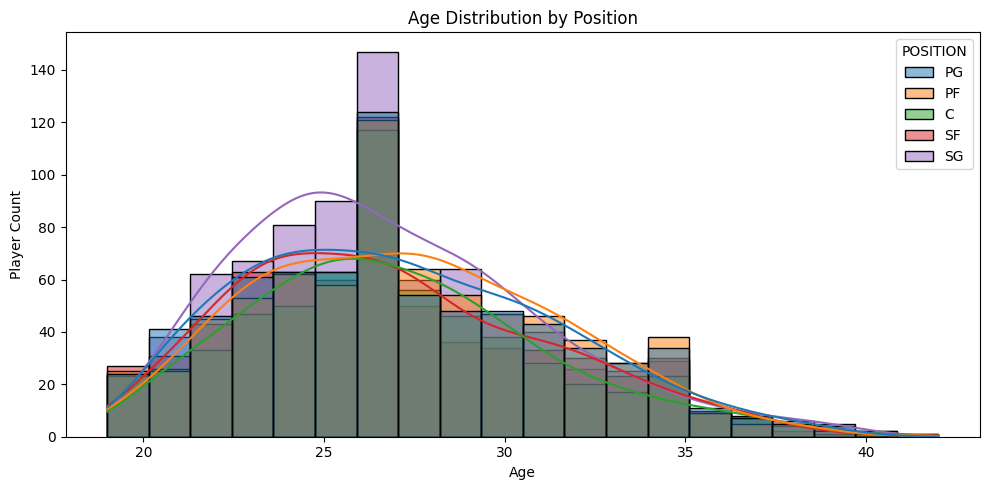

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

nba_final = pd.read_csv("nba_final.csv")

# Age distribution by position
plt.figure(figsize=(10,5))
sns.histplot(data=nba_final, x="AGE", hue="POSITION", bins=20, kde=True)
plt.title("Age Distribution by Position")
plt.xlabel("Age")
plt.ylabel("Player Count")
plt.tight_layout()
plt.savefig("figures/age_distribution.png")
plt.show()

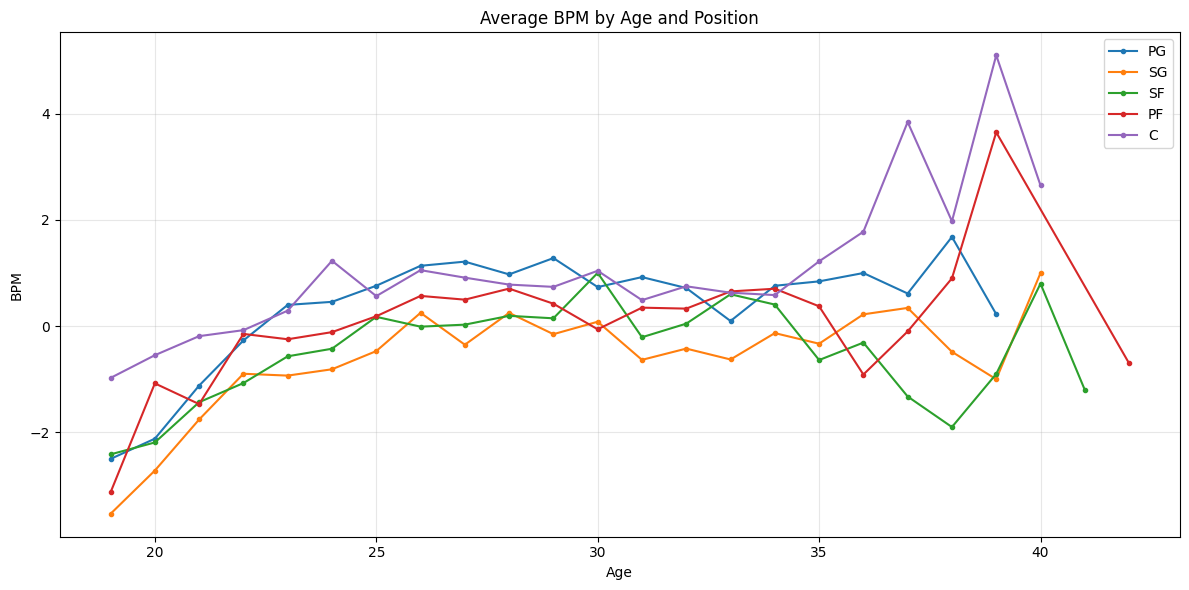

In [10]:
# BPM trend by age and position
plt.figure(figsize=(12,6))
for pos in ["PG", "SG", "SF", "PF", "C"]:
    subset = nba_final[nba_final["POSITION"] == pos]
    age_bpm = subset.groupby("AGE")["BPM"].mean()
    plt.plot(age_bpm.index, age_bpm.values, label=pos, marker="o", markersize=3)

plt.title("Average BPM by Age and Position")
plt.xlabel("Age")
plt.ylabel("BPM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/bpm_by_age_position.png")
plt.show()

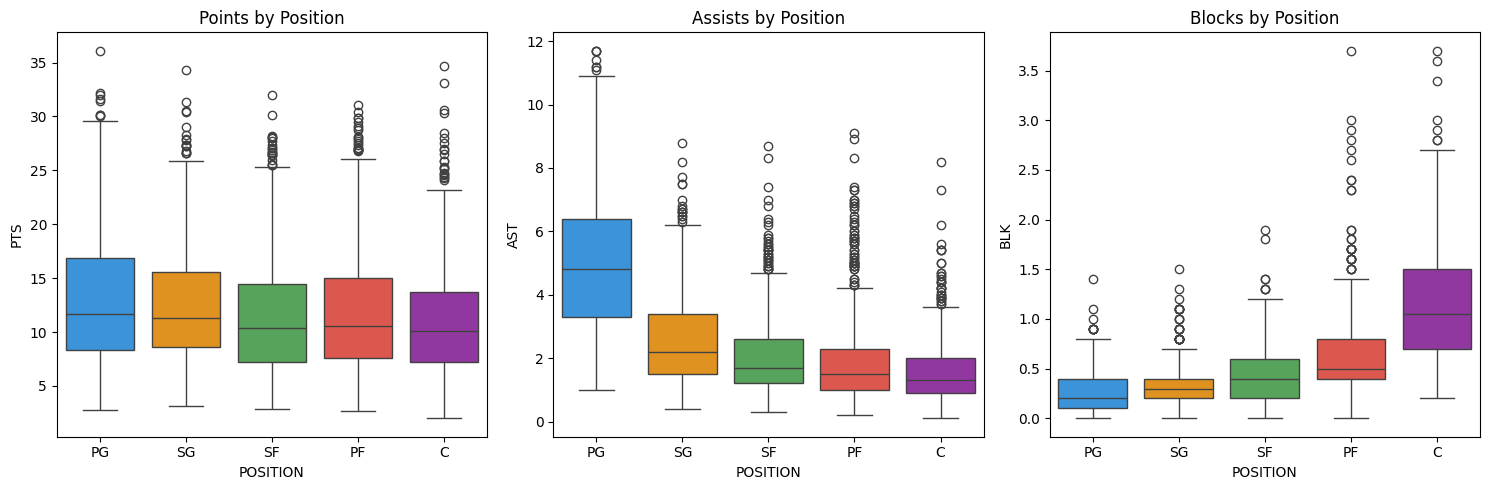

In [11]:
position_colors = {"PG": "#2196F3", "SG": "#FF9800", "SF": "#4CAF50", "PF": "#F44336", "C": "#9C27B0"}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
order = ["PG", "SG", "SF", "PF", "C"]

sns.boxplot(data=nba_final, x="POSITION", y="PTS", hue="POSITION",
            palette=position_colors, ax=axes[0], order=order, legend=False)
axes[0].set_title("Points by Position")

sns.boxplot(data=nba_final, x="POSITION", y="AST", hue="POSITION",
            palette=position_colors, ax=axes[1], order=order, legend=False)
axes[1].set_title("Assists by Position")

sns.boxplot(data=nba_final, x="POSITION", y="BLK", hue="POSITION",
            palette=position_colors, ax=axes[2], order=order, legend=False)
axes[2].set_title("Blocks by Position")

plt.tight_layout()
plt.savefig("figures/stats_by_position.png")
plt.show()

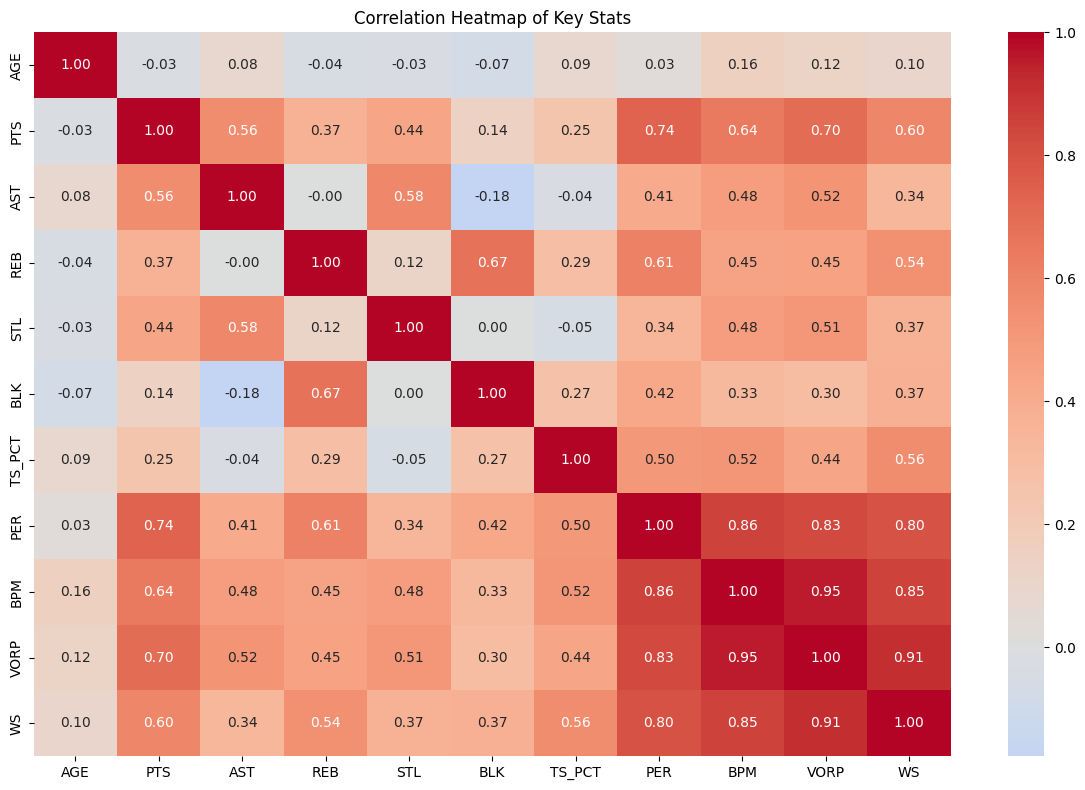

In [12]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
cols = ["AGE", "PTS", "AST", "REB", "STL", "BLK", "TS_PCT", "PER", "BPM", "VORP", "WS"]
sns.heatmap(nba_final[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Key Stats")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png")
plt.show()

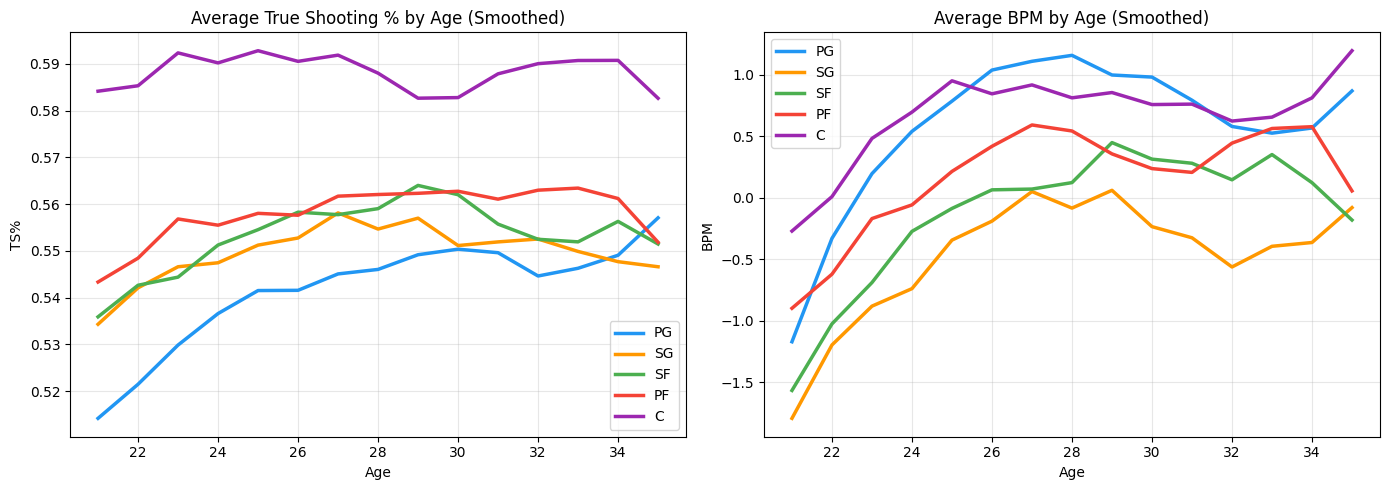

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"PG": "#2196F3", "SG": "#FF9800", "SF": "#4CAF50", "PF": "#F44336", "C": "#9C27B0"}

for pos in ["PG", "SG", "SF", "PF", "C"]:
    subset = nba_final[nba_final["POSITION"] == pos]
    age_ts = subset.groupby("AGE")["TS_PCT"].mean()
    age_bpm = subset.groupby("AGE")["BPM"].mean()

    age_ts = age_ts[(age_ts.index >= 20) & (age_ts.index <= 36)]
    age_bpm = age_bpm[(age_bpm.index >= 20) & (age_bpm.index <= 36)]

    ts_smooth = age_ts.rolling(window=3, center=True).mean()
    bpm_smooth = age_bpm.rolling(window=3, center=True).mean()

    axes[0].plot(ts_smooth.index, ts_smooth.values, label=pos, color=colors[pos], linewidth=2.5)
    axes[1].plot(bpm_smooth.index, bpm_smooth.values, label=pos, color=colors[pos], linewidth=2.5)

axes[0].set_title("Average True Shooting % by Age (Smoothed)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("TS%")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Average BPM by Age (Smoothed)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("BPM")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/trend_age_performance.png")
plt.show()

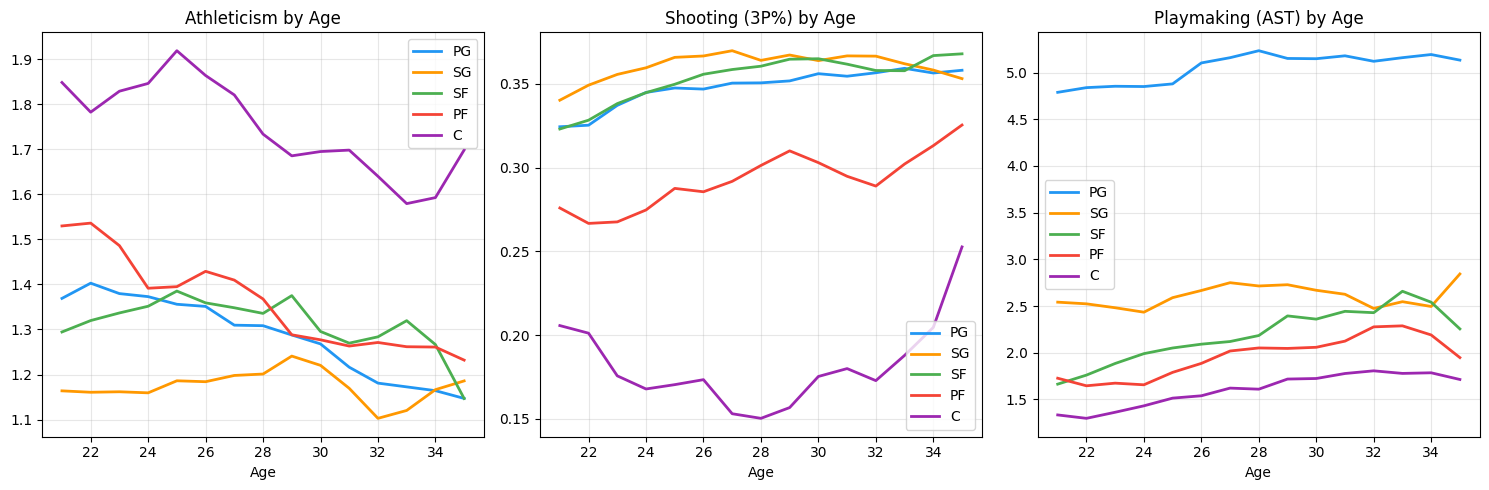

In [14]:
# Skill group analysis by position
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {"PG": "#2196F3", "SG": "#FF9800", "SF": "#4CAF50", "PF": "#F44336", "C": "#9C27B0"}

for pos in ["PG", "SG", "SF", "PF", "C"]:
    subset = nba_final[nba_final["POSITION"] == pos]
    age_grp = subset.groupby("AGE").agg({"STL": "mean", "BLK": "mean", "FG3_PCT": "mean", "AST": "mean"}).reset_index()
    age_grp = age_grp[(age_grp["AGE"] >= 20) & (age_grp["AGE"] <= 36)]

    # Athleticism: STL + BLK
    athleticism = (age_grp["STL"].rolling(3, center=True).mean() + age_grp["BLK"].rolling(3, center=True).mean())
    # Shooting: 3P%
    shooting = age_grp["FG3_PCT"].rolling(3, center=True).mean()
    # Playmaking: AST
    playmaking = age_grp["AST"].rolling(3, center=True).mean()

    axes[0].plot(age_grp["AGE"], athleticism, label=pos, color=colors[pos], linewidth=2)
    axes[1].plot(age_grp["AGE"], shooting, label=pos, color=colors[pos], linewidth=2)
    axes[2].plot(age_grp["AGE"], playmaking, label=pos, color=colors[pos], linewidth=2)

axes[0].set_title("Athleticism by Age")
axes[0].set_xlabel("Age")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Shooting (3P%) by Age")
axes[1].set_xlabel("Age")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Playmaking (AST) by Age")
axes[2].set_xlabel("Age")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/skill_groups_by_age.png")
plt.show()

In [15]:
from scipy import stats

# Hypothesis 1: Do Centers age better than Guards in terms of BPM?
# H0: No difference in BPM decline rate between C and PG
# H1: Centers maintain BPM better with age

centers = nba_final[nba_final["POSITION"] == "C"]["BPM"]
guards = nba_final[nba_final["POSITION"] == "PG"]["BPM"]

t_stat, p_value = stats.ttest_ind(centers, guards)
print("=== C vs PG BPM Comparison ===")
print(f"Centers mean BPM: {centers.mean():.3f}")
print(f"Guards mean BPM: {guards.mean():.3f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference!")
else:
    print("Result: No significant difference.")

=== C vs PG BPM Comparison ===
Centers mean BPM: 0.726
Guards mean BPM: 0.548
T-statistic: 1.191
P-value: 0.2340
Result: No significant difference.


In [16]:
# Hypothesis 2: Does TS% decline with age?
# H0: No correlation between age and TS%
# H1: TS% changes significantly with age

corr, p_value = stats.pearsonr(nba_final["AGE"], nba_final["TS_PCT"])
print("=== Age vs True Shooting % Correlation ===")
print(f"Pearson correlation: {corr:.3f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant correlation!")
else:
    print("Result: No significant correlation.")

# Per position
print("\n=== Age vs TS% by Position ===")
for pos in ["PG", "SG", "SF", "PF", "C"]:
    subset = nba_final[nba_final["POSITION"] == pos]
    corr, p_val = stats.pearsonr(subset["AGE"], subset["TS_PCT"])
    print(f"{pos}: r={corr:.3f}, p={p_val:.4f} {'✓ Significant' if p_val < 0.05 else '✗ Not significant'}")

=== Age vs True Shooting % Correlation ===
Pearson correlation: 0.086
P-value: 0.0000
Result: Significant correlation!

=== Age vs TS% by Position ===
PG: r=0.251, p=0.0000 ✓ Significant
SG: r=0.091, p=0.0085 ✓ Significant
SF: r=0.077, p=0.0460 ✓ Significant
PF: r=0.098, p=0.0082 ✓ Significant
C: r=-0.049, p=0.2253 ✗ Not significant


In [17]:
# Hypothesis 3: Do positions differ significantly in BPM decline after age 28?
# H0: No difference in BPM between positions for players 28+
# H1: Some positions maintain performance better after 28

young = nba_final[nba_final["AGE"] <= 28]
old = nba_final[nba_final["AGE"] > 28]

print("=== BPM: Under 28 vs Over 28 by Position ===")
for pos in ["PG", "SG", "SF", "PF", "C"]:
    young_bpm = young[young["POSITION"] == pos]["BPM"].mean()
    old_bpm = old[old["POSITION"] == pos]["BPM"].mean()
    diff = old_bpm - young_bpm
    print(f"{pos}: Young={young_bpm:.2f}, Old={old_bpm:.2f}, Change={diff:+.2f}")

# ANOVA test
groups = [nba_final[nba_final["POSITION"] == pos]["BPM"].values for pos in ["PG", "SG", "SF", "PF", "C"]]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nANOVA: F={f_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference between positions!")
else:
    print("Result: No significant difference.")

=== BPM: Under 28 vs Over 28 by Position ===
PG: Young=0.40, Old=0.82, Change=+0.42
SG: Young=-0.62, Old=-0.25, Change=+0.37
SF: Young=-0.42, Old=0.13, Change=+0.55
PF: Young=0.03, Old=0.33, Change=+0.30
C: Young=0.60, Old=0.99, Change=+0.40

ANOVA: F=30.423, p=0.0000
Result: Significant difference between positions!


In [18]:
# Hypothesis 4: Do Guards or Bigs age better athletically?
# Comparing STL (guards) and BLK (bigs) decline with age

print("=== Athleticism Decline by Position ===")
athletic_stats = {"PG": "STL", "SG": "STL", "SF": "STL", "PF": "BLK", "C": "BLK"}

for pos, stat in athletic_stats.items():
    subset = nba_final[nba_final["POSITION"] == pos]
    corr, p_val = stats.pearsonr(subset["AGE"], subset[stat])
    print(f"{pos} ({stat} vs Age): r={corr:.3f}, p={p_val:.4f} {'✓ Significant' if p_val < 0.05 else '✗ Not significant'}")

=== Athleticism Decline by Position ===
PG (STL vs Age): r=-0.104, p=0.0045 ✓ Significant
SG (STL vs Age): r=0.007, p=0.8436 ✗ Not significant
SF (STL vs Age): r=-0.013, p=0.7317 ✗ Not significant
PF (BLK vs Age): r=-0.212, p=0.0000 ✓ Significant
C (BLK vs Age): r=-0.055, p=0.1747 ✗ Not significant


In [19]:
from google.colab import files
import os

for f in os.listdir("figures"):
    files.download(f"figures/{f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>